Epoch [1/5], Loss: 6251.4400


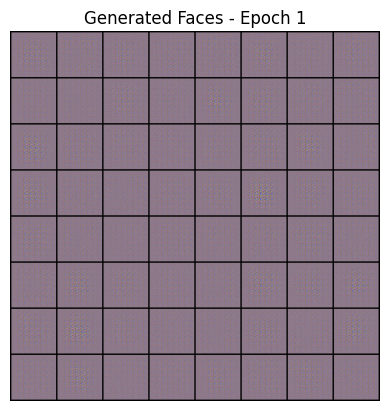

Epoch [2/5], Loss: 3642.5396


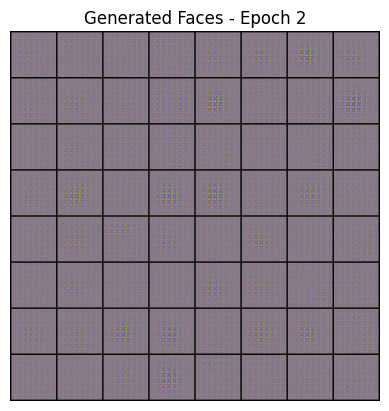

Epoch [3/5], Loss: 3258.2022


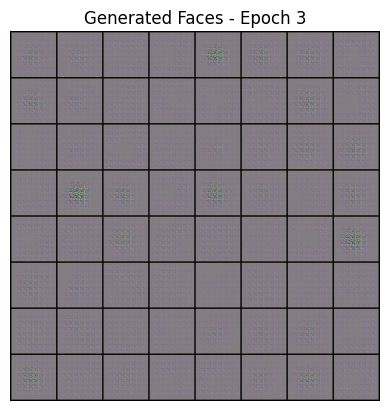

Epoch [4/5], Loss: 3127.1457


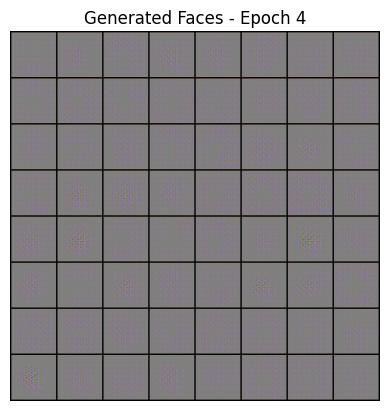

Epoch [5/5], Loss: 3074.5338


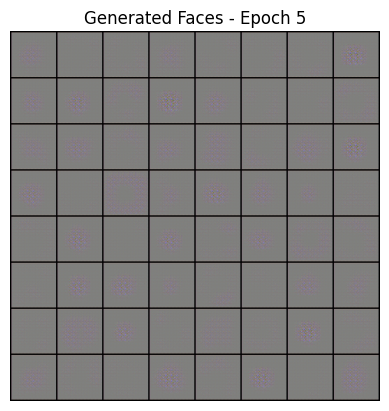

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

# AI23531 Deep Learning Page | 33
# Step 2: Configure Parameters and Load Dataset
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
image_size = 64
batch_size = 128
latent_dim = 100
num_epochs = 5
learning_rate = 1e-3

# Fallback: Create a synthetic dataset simulating CelebA because of GDrive download quota errors
class SyntheticCelebADataset(Dataset):
    def __init__(self, size=500):
        self.size = size
    def __len__(self):
        return self.size
    def __getitem__(self, idx):
        # Return random float tensor representing an image with shape (3, 64, 64) in range [-1, 1]
        img = torch.randn(3, 64, 64) * 0.5
        img = torch.clamp(img, -1.0, 1.0)
        # CelebA returns (image, target) where target is attributes. We return a dummy target 0.
        return img, 0

dataset = SyntheticCelebADataset(size=500)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Step 3: Define Encoder Network
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU()
        )
        self.fc_mu = nn.Linear(512*4*4, latent_dim)
        self.fc_logvar = nn.Linear(512*4*4, latent_dim)
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)

# Step 4: Define Decoder Network
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(latent_dim, 512*4*4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh()
            # AI23531 Deep Learning Page | 34
        )
    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), 512, 4, 4)
        return self.deconv(x)

# Step 5: Define the VAE Model
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

# Step 6: Define Loss Function
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

# Step 7: Train the Model and Generate Images
model = VAE(latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for images, _ in dataloader:
        images = images.to(device)
        recon, mu, logvar = model(images)
        loss = vae_loss(recon, images, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # AI23531 Deep Learning Page | 35
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(dataloader.dataset):.4f}")

    # Generate and visualize samples
    model.eval()
    with torch.no_grad():
        z = torch.randn(64, latent_dim).to(device)
        sample_images = model.decoder(z).cpu() * 0.5 + 0.5 # De-normalize
        grid = torchvision.utils.make_grid(sample_images, nrow=8)
        plt.imshow(grid.permute(1, 2, 0))
        plt.axis('off')
        plt.title(f"Generated Faces - Epoch {epoch+1}")
        plt.show()